# Hate-speech configuration sensitivity

This notebook analyzes the released 14,400-row configuration aggregate. Raw
item-level model outputs are pending the colleague handoff, so this notebook
does not claim to reproduce item-level classification metrics.

**Sensitive-content note:** the underlying corpus contains identity-targeted
hate speech. This aggregate contains target-group labels but no source text.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ANALYSIS = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (ANALYSIS / "data").exists():
    ANALYSIS = Path.cwd() / "tasks" / "hate-speech" / "analysis"
DATA = ANALYSIS / "data"
FIGURES = ANALYSIS / "figures"

scores = pd.read_csv(DATA / "hs_configuration_scores.csv")
sensitivity = pd.read_csv(DATA / "hs_factor_sensitivity.csv")

## Aggregate completeness

The design has 300 sampled configurations for each of six persona conditions
and eight models. Each row is already averaged over the items belonging to the
configuration's sampled target group.

In [2]:
display(scores.head())
display(scores.groupby("model").size().rename("configurations"))
assert len(scores) == 8 * 6 * 300
assert scores.groupby("model").size().eq(1800).all()
assert scores["target"].nunique() == 10

,model,ideology,target,context_combo,instr_combo,persona_combo,mean_p_hate,mean_item_dispersion
0,Qwen/Qwen3-14B,base,asian people,Ctx_4,8,absent,0.372923,0.093060
1,Qwen/Qwen3-14B,base,women,absent,1,absent,0.291968,0.047583
2,Qwen/Qwen3-14B,base,women,Ctx_2,8,absent,0.326751,0.064018
3,Qwen/Qwen3-14B,base,asian people,absent,7,absent,0.385887,0.082547
4,Qwen/Qwen3-14B,base,women,Ctx_2,6,absent,0.335429,0.060716


model
Qwen/Qwen3-14B           1800
Qwen/Qwen3-32B           1800
Qwen/Qwen3-4B            1800
Qwen/Qwen3-8B            1800
google/gemma-3-12b-it    1800
google/gemma-3-1b-it     1800
google/gemma-3-27b-it    1800
google/gemma-3-4b-it     1800
Name: configurations, dtype: int64

## What the sensitivity values mean

`target` is a data-composition block because each configuration samples one
identity target; it is not presented as a prompt manipulation. Within each
persona condition, additive models estimate spread associated with persona
wording, context wording, and instruction wording. `Ideology SD` is the spread
between persona-condition means. `Intrinsic Blur` comes from mean `p(1-p)`
across item probabilities, and `Residual Jitter` is unexplained
configuration-level spread.

The largest component differs by checkpoint. Instruction wording is especially
large for Gemma 3 1B, whereas context or the persona-condition spread is larger
for some other checkpoints. This supports prompt sensitivity and
checkpoint-specific heterogeneity; it does not support a uniform size or
family law.

,model,Mean P(Hate),Total Var SD,Ideology SD,persona_combo_sd,context_combo_sd,instr_combo_sd,Intrinsic Blur,Residual Jitter
0,google/gemma-3-1b-it,0.488316,0.427559,0.074011,0.058706,0.067182,0.218784,0.333674,0.105640
1,google/gemma-3-4b-it,0.359558,0.382654,0.115406,0.077903,0.125666,0.093663,0.293648,0.137566
2,google/gemma-3-12b-it,0.414083,0.266535,0.062732,0.047904,0.061780,0.076146,0.225151,0.072074
3,google/gemma-3-27b-it,0.514876,0.234309,0.060387,0.055744,0.038479,0.060942,0.201814,0.055377
4,Qwen/Qwen3-4B,0.225941,0.372879,0.099133,0.063528,0.075982,0.078155,0.331324,0.065332
5,Qwen/Qwen3-8B,0.409900,0.414722,0.131350,0.079962,0.136001,0.096754,0.334569,0.101115
6,Qwen/Qwen3-14B,0.350842,0.294808,0.016650,0.035521,0.025745,0.067780,0.277140,0.053239
7,Qwen/Qwen3-32B,0.502613,0.383953,0.032166,0.016945,0.046008,0.061589,0.372319,0.044967


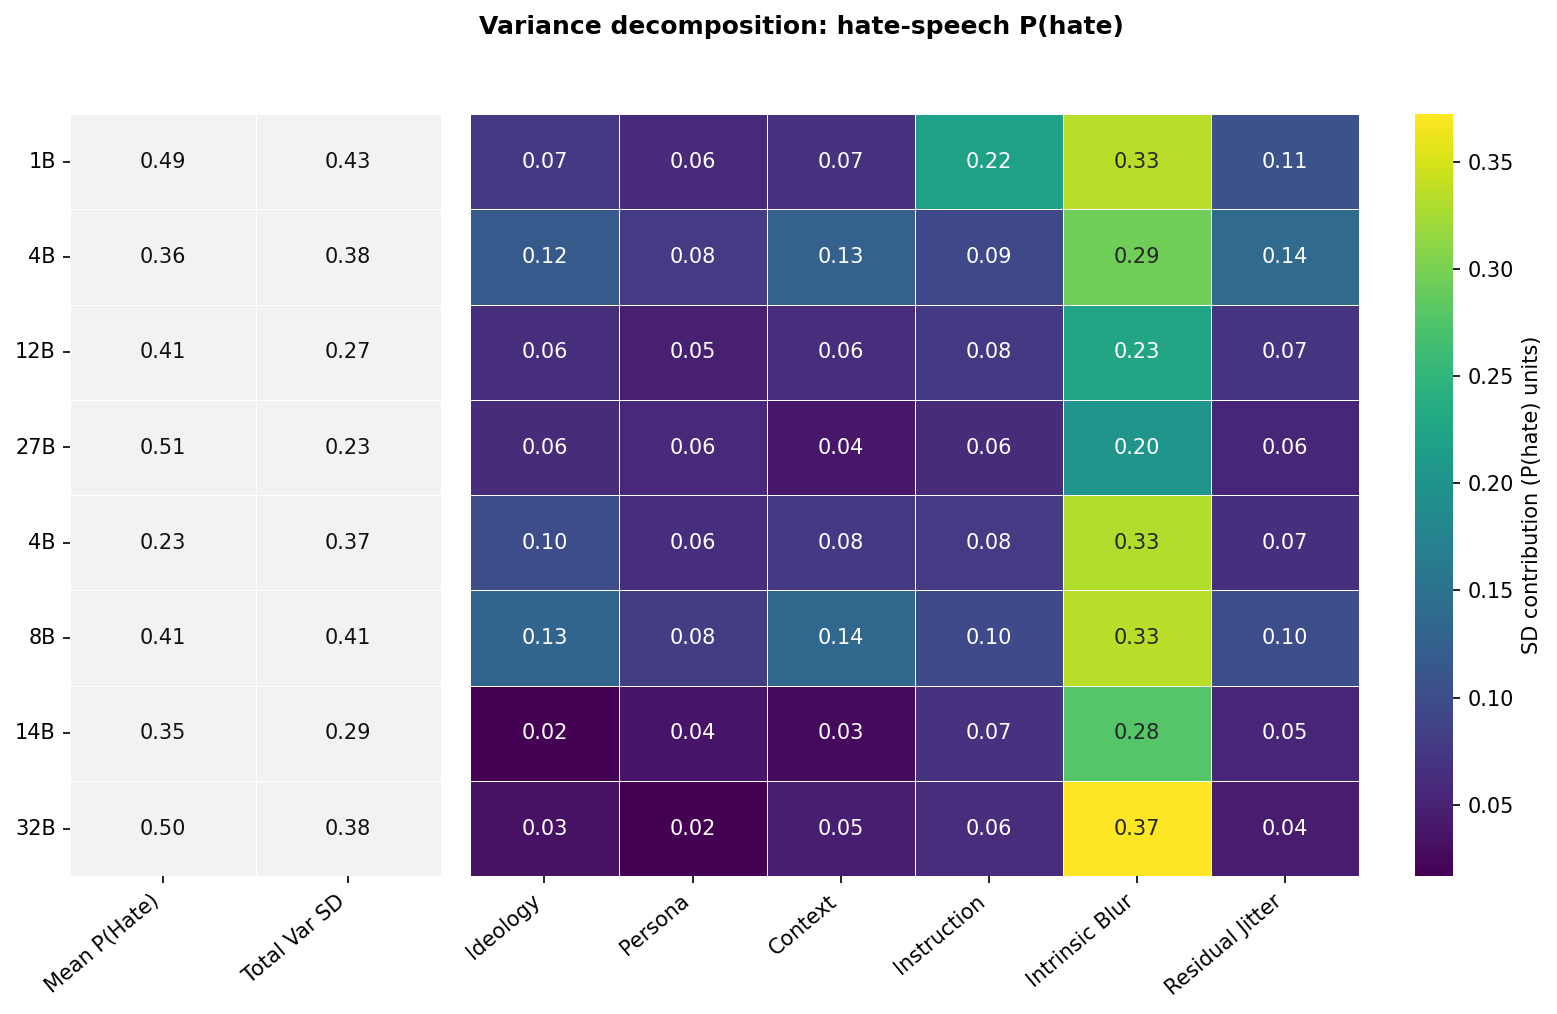

In [3]:
columns = [
    "model", "Mean P(Hate)", "Total Var SD", "Ideology SD",
    "persona_combo_sd", "context_combo_sd", "instr_combo_sd",
    "Intrinsic Blur", "Residual Jitter",
]
display(sensitivity[columns])
display(Image(filename=str(FIGURES / "hate_speech_factor_sensitivity.png")))

## Limits

The very small model-fit p-values are not the main scientific claim: there are
many repeated configurations, and statistical detectability does not imply a
large or general effect. The component magnitudes and their inconsistency
across checkpoints are the more useful descriptive result. Item-level AUC,
F1, calibration, and target-level metrics must be regenerated after the raw
outputs and exact corpus are supplied and validated.